# TensorBinding — Imaging various band structures

Band structure examples using the **TensorBinding** MPO framework with Chebyshev KPM.

The k-resolved spectral function  $A(\mathbf{k},\omega)$ is computed via diagonal extraction after QFT conjugation of the Chebyshev MPOs.  Each example demonstrates a different combination of auxiliary-index projections (spin, layer, sublattice, Nambu).

Note: Since this is a Julia notebook, you may want to first run the cells with smaller system sizes, as the initial execution includes function precompilation overhead.

In [1]:
using LinearAlgebra
using Plots
using LaTeXStrings
using ITensors
using ITensorMPS
include("../../src/TensorBinding.jl") # if you have the package installed, you can directly do using TensorBinding
using .TensorBinding
using QuanticsTCI
import TensorCrossInterpolation as TCI

---
## Example 1 — 1D chain with Zeeman field (spin projection)

A nearest-neighbour tight-binding chain with a uniform Zeeman field $h S_z$.  The field splits the single cosine band into two spin-resolved copies:

$$E_\pm(k) = -2t\cos k \pm h$$

The spin site is prepended via `add_zeeman!` (which calls `add_spin!` internally).  `spin_proj=true` projects each Chebyshev MPO onto spin-up ($\sigma=1$) or spin-down ($\sigma=2$) before the QFT, giving $A_\uparrow(k,\omega)$ and $A_\downarrow(k,\omega)$ separately.

In [2]:
L  = 5
H1 = TensorBinding.get_Hamiltonian("chain_1d", 1.0; L=L, scale=4.5)
println(H1)

soc = 1.0

TensorBinding.add_zeeman!(H1, soc; direction=:z,
tol=1e-8, maxdim=200)

## Create three spin projections: 1) no projection, 2) spin-up, 3) spin-down

Ncheb  = 30
maxdim = 100

e_phys = range(-3, 3; length=100)

Ak1 = TensorBinding.get_bands(H1,
                          Ncheb, 1, e_phys; num_x = 2^L, spin_proj=false, proj_s=nothing);

Ak2 = TensorBinding.get_bands(H1,
                          Ncheb, 1, e_phys; num_x = 2^L, spin_proj=true, proj_s=1);

Ak3 = TensorBinding.get_bands(H1,
                          Ncheb, 1, e_phys; num_x = 2^L, spin_proj=true, proj_s=2);

TBHamiltonian | L=5, N=32, scale=4.5, maxlinkdim=3 | geometry: 32 sites, 1D | no Tn cache
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -2.4909,  E_max = 2.4908
  center = -0.0,  scale = 2.7399
Info: H.spin_s detected; auto-enabling spin_proj=true (pass proj_s=1/2 to select ↑/↓ sector).


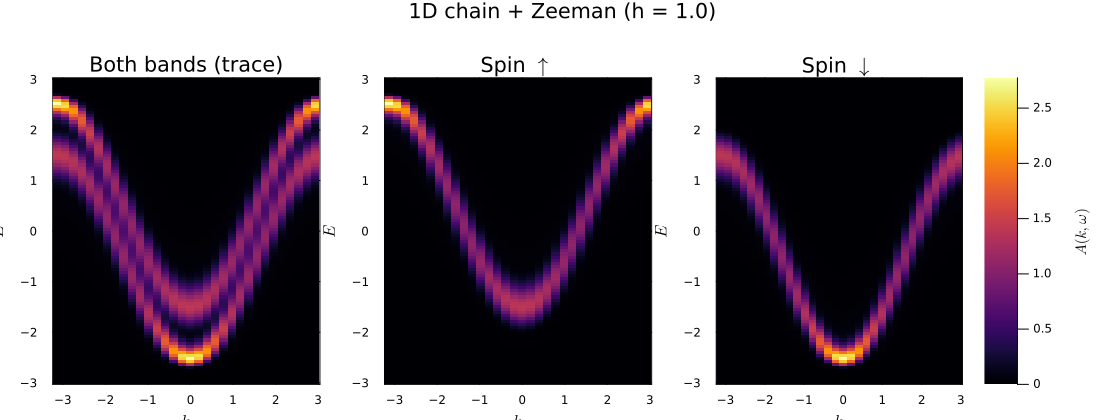

In [3]:
# Spin convention:  state 1 = ↑ ,  state 2 = ↓   (see _SPIN_OPS in Supercond_tk.jl)
# Ak1 → both bands (no spin projection, full trace)
# Ak2 → spin-↑ only  (proj_s=1)
# Ak3 → spin-↓ only  (proj_s=2)

kvals_z = (2π / 2^L) .* (0:2^L-1) .- π
vmax_z  = max(maximum(Ak1), maximum(Ak2), maximum(Ak3))

common_z = (color=:inferno, clims=(0, vmax_z), xlabel=L"k", ylabel=L"E",
            framestyle=:box, colorbar=false, flipy=true)

p1 = heatmap(kvals_z, e_phys, Ak1; title="Both bands (trace)",        common_z...)
p2 = heatmap(kvals_z, e_phys, Ak2; title=L"Spin $\uparrow$", common_z...)
p3 = heatmap(kvals_z, e_phys, Ak3; title=L"Spin $\downarrow$",
             color=:inferno, clims=(0, vmax_z), xlabel=L"k", ylabel=L"E",
             framestyle=:box, colorbar=true, flipy=true,
             cbar_title=L"A(k,\omega)", cbar_titlefontsize=12)

ptitle = plot(title="1D chain + Zeeman (h = $(soc))",
              framestyle=:none, grid=false, showaxis=false, bottom_margin=-15Plots.px)

l = @layout [A{0.07h}; [a b c{0.40w}]]
plot(ptitle, p1, p2, p3; layout=l, size=(1100, 420))

---
## Example 2 — SSH chain with Zeeman field (sublattice mask + spin projection)

The Su-Schrieffer-Heeger (SSH) model alternates hopping amplitudes $t \pm \delta$, producing two bands separated by a gap $2|\delta|$ in the zone-folded Brillouin zone:

$$E_\pm(k) = \pm\sqrt{t^2 + \delta^2 + 2t\delta\cos k}$$

Adding a Zeeman field $h$ further splits each band by $2h$, yielding four bands total.

**Sublattice projection** (`sublattice=true`) uses the legacy mask sandwich $\text{mask}_A \cdot T_n \cdot \text{mask}_A$ (appropriate for preset models without an explicit sublattice auxiliary index).  Combining with `spin_proj` gives the four channels $A_{A\uparrow},\,A_{A\downarrow},\,A_{B\uparrow},\,A_{B\downarrow}$.

In [4]:
L  = 6
t1 = 1.0
t2 = 0.5

H1 = TensorBinding.get_Hamiltonian("ssh", Dict(:t => 1, :d => t2), L=L; scale=5.5)
TensorBinding.truncate!(H1; cutoff=1e-6)

Ncheb  = 30
maxdim = 100

e_phys = range(-3, 3; length=100)

# Ak = TensorBinding.get_bands(H1,
#                           Ncheb, 1, e_phys; num_x = 2^L, sublattice=true, proj_sl=1);

soc = 1.0

TensorBinding.add_zeeman!(H1, soc; direction=:z,
tol=1e-8, maxdim=200)

Ak1 = TensorBinding.get_bands(H1,
                          Ncheb, 1, e_phys; num_x = 2^L, sublattice=true, spin_proj=false, proj_s=nothing);

Ak2 = TensorBinding.get_bands(H1,
                          Ncheb, 1, e_phys; num_x = 2^L, sublattice=true, spin_proj=true, proj_s=1);

Ak3 = TensorBinding.get_bands(H1,
                          Ncheb, 1, e_phys; num_x = 2^L, sublattice=true, spin_proj=true, proj_s=2);

KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -2.4967,  E_max = 2.4937
  center = -0.0015,  scale = 2.7447
Info: H.spin_s detected; auto-enabling spin_proj=true (pass proj_s=1/2 to select ↑/↓ sector).


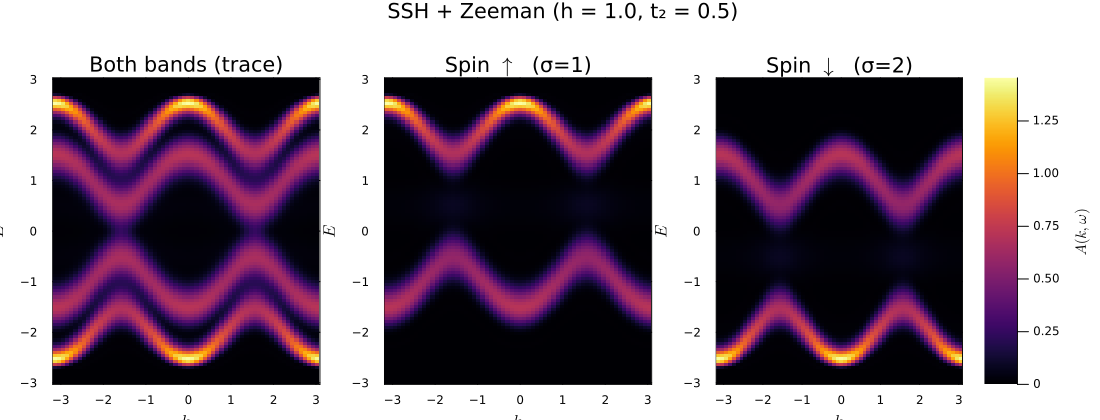

In [5]:
# Ak1 → both bands (trace), Ak2 → spin-↑ (proj_s=1), Ak3 → spin-↓ (proj_s=2)

kvals_ssh = (2π / 2^L) .* (0:2^L-1) .- π
vmax_ssh  = max(maximum(Ak1), maximum(Ak2), maximum(Ak3))

common_ssh = (color=:inferno, clims=(0, vmax_ssh), xlabel=L"k", ylabel=L"E",
              framestyle=:box, colorbar=false, flipy=true)

p1 = heatmap(kvals_ssh, e_phys, Ak1; title="Both bands (trace)",        common_ssh...)
p2 = heatmap(kvals_ssh, e_phys, Ak2; title=L"Spin $\uparrow$  (σ=1)", common_ssh...)
p3 = heatmap(kvals_ssh, e_phys, Ak3; title=L"Spin $\downarrow$  (σ=2)",
             color=:inferno, clims=(0, vmax_ssh), xlabel=L"k", ylabel=L"E",
             framestyle=:box, colorbar=true, flipy=true,
             cbar_title=L"A(k,\omega)", cbar_titlefontsize=12)

ptitle = plot(title="SSH + Zeeman (h = $(soc), t₂ = $(t2))",
              framestyle=:none, grid=false, showaxis=false, bottom_margin=-15Plots.px)

l = @layout [A{0.07h}; [a b c{0.40w}]]
plot(ptitle, p1, p2, p3; layout=l, size=(1100, 420))

---
## Example 3 — 2D flat-band lattices along high-symmetry lines

Four lattices on the triangular or square Bravais lattice, all built with an explicit **sublattice auxiliary index**.  The `sublat_proj=true` flag sums the aux-projected spectral contributions over all sublattice channels before the QFT.

| Lattice   | Bravais    | BZ path  | Flat band | Dispersive bands |
|-----------|------------|----------|-----------|-----------------|
| Honeycomb | triangular | $\Gamma–M–K–\Gamma$  | none (Dirac cone at K) | $\pm t\,\|h(k)\|$ |
| Kagome    | triangular | $\Gamma–M–K–\Gamma$  | $E = -2t$ | up to $+4t$ |
| Lieb      | square     | $\Gamma–X–M–\Gamma$  | $E = 0$   | $\pm 2t\,\|\sin(k/2)\|$ |
| Dice (T3) | triangular | $\Gamma–M–K–\Gamma$  | $E = 0$ (doubly degenerate) | $\pm 3t$ |

The `kpath` shortcut passes high-symmetry symbols directly to `get_bands`; the returned `NamedTuple` carries `.Ak`, `.ticks`, and `.labels`.

In [6]:
L = 8; Lx = 4; Ly = L - Lx

HH = TensorBinding.get_Hamiltonian("honeycomb", 1.0, L=L, Lx=Lx; scale=5.5)
TensorBinding.truncate!(HH; cutoff=1e-6)

HK = TensorBinding.get_Hamiltonian("kagome",    1.0, L=L, Lx=Lx; scale=5.5)
TensorBinding.truncate!(HK; cutoff=1e-6)

HL = TensorBinding.get_Hamiltonian("lieb",      1.0, L=L, Lx=Lx; scale=5.5)
TensorBinding.truncate!(HL; cutoff=1e-6)

HD = TensorBinding.dice_hamiltonian(Lx, Ly, 1.0)
TensorBinding.truncate!(HD; cutoff=1e-6)

Ncheb  = 30
e_phys = range(-6, 6; length=100)

resH = TensorBinding.get_bands(HH, Ncheb, 2, e_phys;
           sublat_proj=true, kpath=[:G, :M, :Kp, :G], kpath_lattice=:honeycomb, num_x=20);

resK = TensorBinding.get_bands(HK, Ncheb, 2, e_phys;
           sublat_proj=true, kpath=[:G, :M, :Kp, :G], kpath_lattice=:honeycomb, num_x=20);

resL = TensorBinding.get_bands(HL, Ncheb, 2, e_phys;
           sublat_proj=true, kpath=[:G, :X, :M, :G], kpath_lattice=:square, num_x=20);

resD = TensorBinding.get_bands(HD, Ncheb, 2, e_phys;
           sublat_proj=true, kpath=[:G, :M, :Kp, :G], kpath_lattice=:honeycomb, num_x=20);


KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -2.9776,  E_max = 2.9774
  center = -0.0001,  scale = 3.2753
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -2.0,  E_max = 3.9772
  center = 0.9886,  scale = 3.2874
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -2.8123,  E_max = 2.8131
  center = 0.0004,  scale = 3.0939
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -4.2029,  E_max = 4.2101
  center = 0.0036,  scale = 4.6272


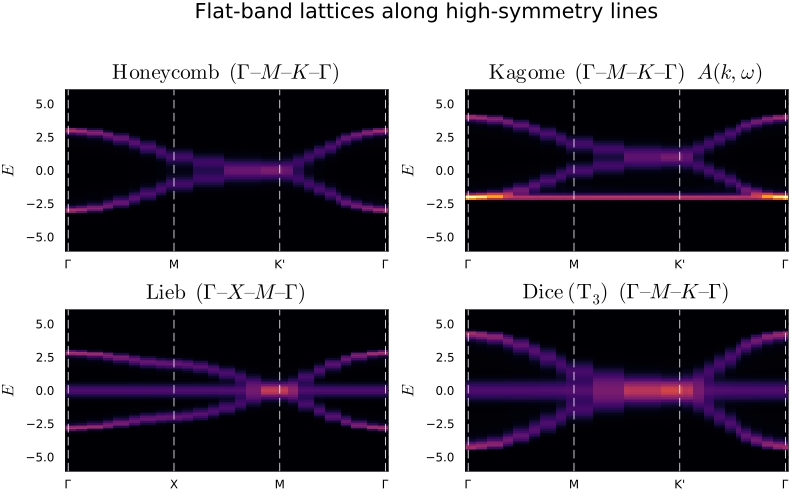

In [7]:
vmax_3 = max(maximum(resH.Ak), maximum(resK.Ak), maximum(resL.Ak), maximum(resD.Ak))

common = (color=:inferno, clims=(0, vmax_3), ylabel=L"E",
          framestyle=:box, colorbar=false, flipy=true)

pH = heatmap(1:size(resH.Ak, 2), e_phys, resH.Ak;
             title=L"\mathrm{Honeycomb} \ \  (\Gamma–M–K–\Gamma)",
             xticks=(resH.ticks, resH.labels), common...)
vline!(pH, resH.ticks; ls=:dash, color=:white, lw=0.8, label="")

# Kagome carries the shared colorbar (top placement, compact)
pK = heatmap(1:size(resK.Ak, 2), e_phys, resK.Ak;
             title=L"\mathrm{Kagome} \ \  (\Gamma–M–K–\Gamma)   \ \ A(k,\omega)",
             xticks=(resK.ticks, resK.labels),
             color=:inferno, clims=(0, vmax_3), ylabel=L"E",
             framestyle=:box, colorbar=false, colorbar_title="",
             colorbar_titlefontsize=10, flipy=true)
vline!(pK, resK.ticks; ls=:dash, color=:white, lw=0.8, label="")

pL = heatmap(1:size(resL.Ak, 2), e_phys, resL.Ak;
             title=L"\mathrm{Lieb} \ \  (\Gamma–X–M–\Gamma)",
             xticks=(resL.ticks, resL.labels), common...)
vline!(pL, resL.ticks; ls=:dash, color=:white, lw=0.8, label="")

pD = heatmap(1:size(resD.Ak, 2), e_phys, resD.Ak;
             title=L"\mathrm{Dice \ (T_3)} \ \  (\Gamma–M–K–\Gamma)",
             xticks=(resD.ticks, resD.labels), common...)
vline!(pD, resD.ticks; ls=:dash, color=:white, lw=0.8, label="")

ptitle = plot(title="Flat-band lattices along high-symmetry lines",
              framestyle=:none, grid=false, showaxis=false, bottom_margin=-15Plots.px)

# Simple 2×2 grid — row-major order: HC, Kagome, Lieb, Dice
l = @layout [A{0.05h}; grid(2, 2)]
plot(ptitle, pH, pK, pL, pD; layout=l, size=(800, 500))

---
## Example 4 — Kitaev chain: spinless p-wave BdG

The 1D Kitaev chain is the canonical model for topological superconductivity.  The BdG Hamiltonian in the Nambu basis $\Psi = (c,\,c^\dagger)^T$ is

$$H_\text{BdG} = \tau_z \otimes H_\text{kin} + \tau_+ \otimes \Delta_\text{pair} + \tau_- \otimes \Delta_\text{pair}^\dagger$$

where $\Delta_\text{pair}$ is the pairing matrix.  The quasiparticle gap is $2\Delta$ and closes at the topological transition $|\mu| = 2t$.

`nambu_proj=true` projects each Chebyshev MPO onto the particle ($\sigma=1$) or hole ($\sigma=2$) sector; the particle and hole bands are mirror images about $E=0$.

In [8]:
L = 5       # position qubits → N = 2^L = 256 sites
N = 2^L
t = 1.0     # NN hopping amplitude
Δ = 1.0     # p-wave pairing amplitude
μ = -1.0    # chemical potential  (topological phase: |μ| < 2t)

H = TensorBinding.get_Hamiltonian("chain_1d", -t; L=L)   # H = -t(A + A†), OBC
TensorBinding.add_onsite!(H, _ -> -μ)                     # → H_kin = -t(A+A†) - μI

# p-wave pairing: H_pair[i+1, i] = Δ 
# Δ_pair(i, j) = i == j + 1 ? ComplexF64(Δ) : 0.001
TensorBinding.add_superconductivity!(H, Δ)

Ncheb  = 30
maxdim = 100

e_phys = range(-6, 6; length=100)

Ak1 = TensorBinding.get_bands(H,
                          Ncheb, 1, e_phys; num_x = 2^L, nambu_proj=true, proj_nambu=nothing);

Ak2 = TensorBinding.get_bands(H,
                          Ncheb, 1, e_phys; num_x = 2^L, nambu_proj=true, proj_nambu=1);

Ak3 = TensorBinding.get_bands(H,
                          Ncheb, 1, e_phys; num_x = 2^L, nambu_proj=true, proj_nambu=2);

Info: on-site (s-wave) pairing is forbidden for spinless fermions (Δ(i,i) = 0 by Fermi antisymmetry).  Constructing nearest-neighbour p-wave instead.
KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -2.9964,  E_max = 2.9941
  center = -0.0011,  scale = 3.2948


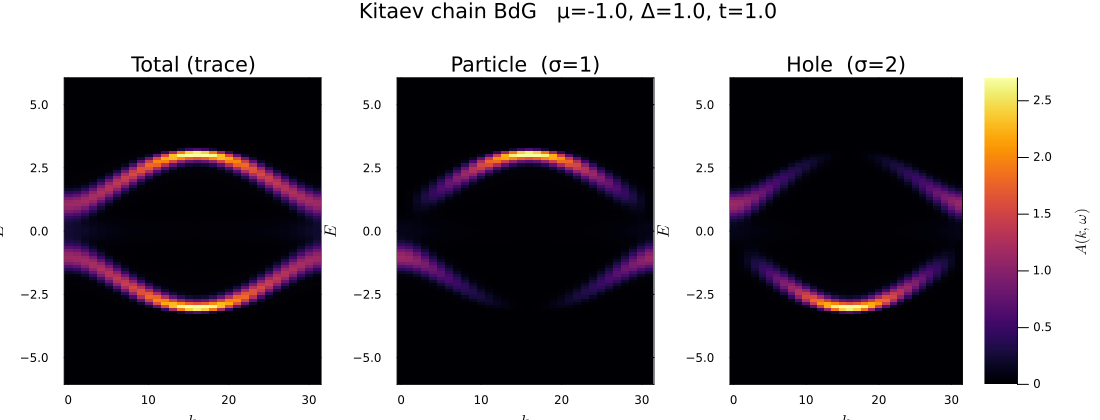

In [9]:
# Nambu convention:  state 1 = particle,  state 2 = hole  (see _NAMBU_OPS in Supercond_tk.jl)
# Ak1 → total (particle + hole trace)
# Ak2 → proj_nambu=1 → particle sector
# Ak3 → proj_nambu=2 → hole sector

Nk_sc    = size(Ak1, 2)
kvals_sc = 0:Nk_sc-1
vmax_sc  = max(maximum(Ak1), maximum(Ak2), maximum(Ak3))

common_sc = (color=:inferno, clims=(0, vmax_sc), xlabel=L"k", ylabel=L"E",
             framestyle=:box, colorbar=false, flipy=true)

p1 = heatmap(kvals_sc, e_phys, Ak1; title="Total (trace)",   common_sc...)
p2 = heatmap(kvals_sc, e_phys, Ak2; title="Particle  (σ=1)", common_sc...)
p3 = heatmap(kvals_sc, e_phys, Ak3; title="Hole  (σ=2)",
             color=:inferno, clims=(0, vmax_sc), xlabel=L"k", ylabel=L"E",
             framestyle=:box, colorbar=true, flipy=true,
             cbar_title=L"A(k,\omega)", cbar_titlefontsize=12)

# Canonical Plots.jl suptitle trick: thin invisible panel carries the global title
ptitle = plot(title="Kitaev chain BdG   μ=$(μ), Δ=$(Δ), t=$(t)",
              framestyle=:none, grid=false, showaxis=false,
              bottom_margin=-15Plots.px)

l = @layout [A{0.07h}; [a b c{0.40w}]]
plot(ptitle, p1, p2, p3; layout=l, size=(1100, 420))

---
## Example 6 — Square bilayer with AA stacking (layer projection)

Two layers of a square lattice coupled by uniform on-site interlayer hopping $t_\perp$.  AA stacking corresponds to $V = t_\perp I$ (identity in position space), which simply splits every single-layer band into bonding and antibonding copies:

$$E_\pm(k) = E_\text{mono}(k) \pm t_\perp$$

The layer index is prepended via `bilayer_hamiltonian` and stored in `H.layer_s`.  `layer_proj=true` projects the Chebyshev MPO onto each individual layer before the QFT; the total spectral function (both layers summed) shows the full bilayer spectrum.

In [10]:
L = 8; Lx = 4; Ly = L - Lx

HblS = TensorBinding.bilayer_hamiltonian(:square, Lx, Ly; t_inter=1.0)
e_phys = range(-6, 6; length=50)

res_bl  = TensorBinding.get_bands(HblS, Ncheb, 2, e_phys;
              layer_proj=true, kpath=[:G, :X, :M, :G], kpath_lattice=:square, num_x=20);
res_bl1 = TensorBinding.get_bands(HblS, Ncheb, 2, e_phys;
              layer_proj=true, proj_layer=1, kpath=[:G, :X, :M, :G], kpath_lattice=:square, num_x=20);
res_bl2 = TensorBinding.get_bands(HblS, Ncheb, 2, e_phys;
              layer_proj=true, proj_layer=2, kpath=[:G, :X, :M, :G], kpath_lattice=:square, num_x=20);

KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -4.9319,  E_max = 4.9319
  center = -0.0,  scale = 5.4251


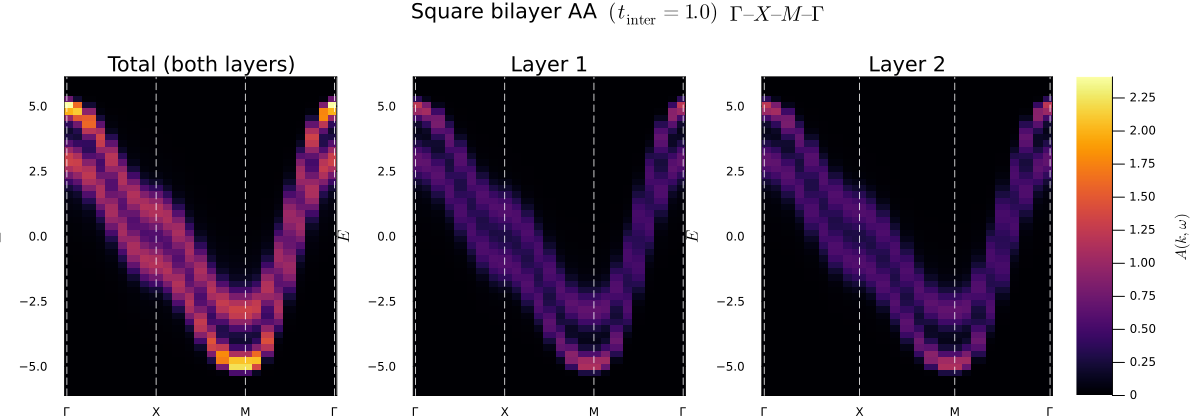

In [11]:
vmax_bl = max(maximum(res_bl.Ak), maximum(res_bl1.Ak), maximum(res_bl2.Ak))

common_bl = (color=:inferno, clims=(0, vmax_bl), ylabel=L"E",
             framestyle=:box, colorbar=false, flipy=true,
             xticks=(res_bl.ticks, res_bl.labels))

pb1 = heatmap(1:size(res_bl.Ak,  2), e_phys, res_bl.Ak;  title="Total (both layers)", common_bl...)
vline!(pb1, res_bl.ticks; ls=:dash, color=:white, lw=0.8, label="")

pb2 = heatmap(1:size(res_bl1.Ak, 2), e_phys, res_bl1.Ak; title="Layer 1", common_bl...)
vline!(pb2, res_bl.ticks; ls=:dash, color=:white, lw=0.8, label="")

pb3 = heatmap(1:size(res_bl2.Ak, 2), e_phys, res_bl2.Ak; title="Layer 2",
              color=:inferno, clims=(0, vmax_bl), ylabel=L"E",
              framestyle=:box, colorbar=true, flipy=true,
              xticks=(res_bl.ticks, res_bl.labels),
              cbar_title=L"A(k,\omega)", cbar_titlefontsize=12)
vline!(pb3, res_bl.ticks; ls=:dash, color=:white, lw=0.8, label="")

ptitle = plot(title="Square bilayer AA  " * L"(t_\mathrm{inter} = 1.0) \ "  *   L"\ \Gamma–X–M–\Gamma",
              framestyle=:none, grid=false, showaxis=false, bottom_margin=-15Plots.px)

l = @layout [A{0.07h}; [a b c{0.43w}]]
plot(ptitle, pb1, pb2, pb3; layout=l, size=(1200, 420))

---
## Example 7 — Honeycomb bilayer with Bernal stacking

Bernal (AB) stacking couples each A-site of layer 1 to the B-site directly above it in layer 2.  The position-space interlayer MPO is

$$V = t_\perp \left( K_u D_A + D_A K_d \right)$$

where $D_A$ is the A-sublattice projector and $K_u/K_d$ are unit shift operators.  Unlike AA stacking, Bernal coupling mixes sublattice character between layers and opens a gap at the Dirac points when $t_\perp \neq 0$.

Here `layer_proj + sublattice=true` gives layer- and sublattice-resolved spectra simultaneously.  The legacy `sublattice=true` mask is used because `bilayer_hamiltonian` builds the honeycomb with the flat preset encoding (no explicit sublattice aux index).

In [12]:
Lx_hb = 4; Ly_hb = 4

HblHB = TensorBinding.bilayer_hamiltonian(:honeycomb, Lx_hb, Ly_hb;
            stacking=:Bernal, t_inter=1.0)
e_phys_hb = range(-6, 6; length=50)

res_hb  = TensorBinding.get_bands(HblHB, Ncheb, 2, e_phys_hb;
              layer_proj=true, sublattice=true,
              kpath=[:G, :M, :Kp, :G], kpath_lattice=:honeycomb, num_x=20);
res_hb1 = TensorBinding.get_bands(HblHB, Ncheb, 2, e_phys_hb;
              layer_proj=true, proj_layer=1, sublattice=true,
              kpath=[:G, :M, :Kp, :G], kpath_lattice=:honeycomb, num_x=20);
res_hb2 = TensorBinding.get_bands(HblHB, Ncheb, 2, e_phys_hb;
              layer_proj=true, proj_layer=2, sublattice=true,
              kpath=[:G, :M, :Kp, :G], kpath_lattice=:honeycomb, num_x=20);

KPM_Tn: estimating spectral bounds via DMRG…
  E_min = -3.9446,  E_max = 3.9454
  center = 0.0004,  scale = 4.3395


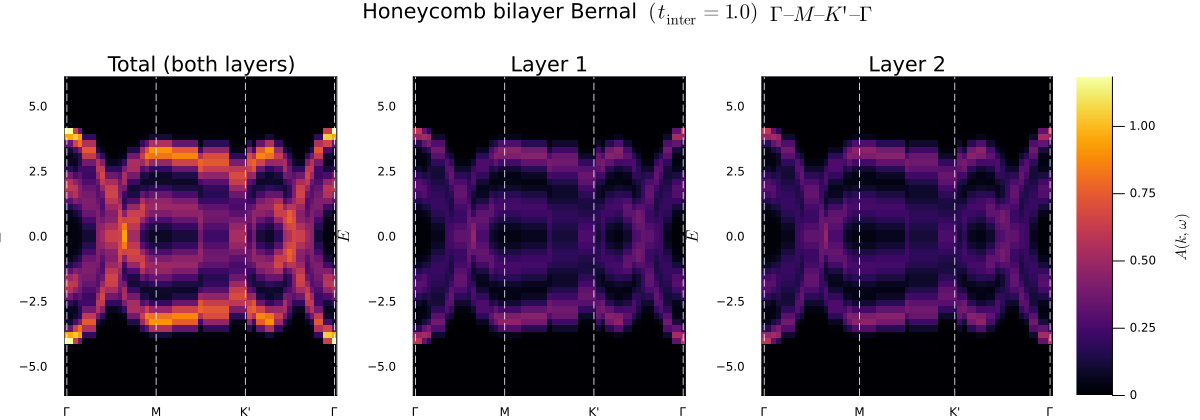

In [13]:
vmax_hb = max(maximum(res_hb.Ak), maximum(res_hb1.Ak), maximum(res_hb2.Ak))

common_hb = (color=:inferno, clims=(0, vmax_hb), ylabel=L"E",
             framestyle=:box, colorbar=false, flipy=true,
             xticks=(res_hb.ticks, res_hb.labels))

ph1 = heatmap(1:size(res_hb.Ak,  2), e_phys_hb, res_hb.Ak;  title="Total (both layers)", common_hb...)
vline!(ph1, res_hb.ticks; ls=:dash, color=:white, lw=0.8, label="")

ph2 = heatmap(1:size(res_hb1.Ak, 2), e_phys_hb, res_hb1.Ak; title="Layer 1", common_hb...)
vline!(ph2, res_hb.ticks; ls=:dash, color=:white, lw=0.8, label="")

ph3 = heatmap(1:size(res_hb2.Ak, 2), e_phys_hb, res_hb2.Ak; title="Layer 2",
              color=:inferno, clims=(0, vmax_hb), ylabel=L"E",
              framestyle=:box, colorbar=true, flipy=true,
              xticks=(res_hb.ticks, res_hb.labels),
              cbar_title=L"A(k,\omega)", cbar_titlefontsize=12)
vline!(ph3, res_hb.ticks; ls=:dash, color=:white, lw=0.8, label="")

ptitle = plot(title="Honeycomb bilayer Bernal  " * L"(t_\mathrm{inter} = 1.0) \ "
                    *   L"\ \Gamma–M–K'–\Gamma",
              framestyle=:none, grid=false, showaxis=false, bottom_margin=-15Plots.px)

l = @layout [A{0.07h}; [a b c{0.43w}]]
plot(ptitle, ph1, ph2, ph3; layout=l, size=(1200, 420))